In [ ]:
%pip install pandas

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error


In [14]:
np.random.seed(42)
dates = pd.date_range(start = '2020-01-01', periods = 36, freq = 'ME')
sales = 200+15*np.arange(36) + np.random.randint(-50,50,36)

df = pd.DataFrame({"date":dates, 'store': 1, 'items' : 1, 'sales':sales})
df.to_csv("train.csv", index = False)

df.head()

,date,store,items,sales
0,2020-01-31,1,1,201
1,2020-02-29,1,1,257
2,2020-03-31,1,1,194
3,2020-04-30,1,1,266
4,2020-05-31,1,1,270


In [15]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    36 non-null     datetime64[ns]
 1   store   36 non-null     int64         
 2   items   36 non-null     int64         
 3   sales   36 non-null     int32         
dtypes: datetime64[ns](1), int32(1), int64(2)
memory usage: 1.1 KB


In [17]:
df.isnull().sum()

date     0
store    0
items    0
sales    0
dtype: int64

In [18]:
df.describe()

,date,store,items,sales
count,36,36.0,36.0,36.000000
mean,2021-07-15 21:20:00,1.0,1.0,466.500000
min,2020-01-31 00:00:00,1.0,1.0,194.000000
25%,2020-10-23 06:00:00,1.0,1.0,346.250000
50%,2021-07-15 12:00:00,1.0,1.0,450.000000
75%,2022-04-07 12:00:00,1.0,1.0,597.750000
max,2022-12-31 00:00:00,1.0,1.0,754.000000
std,NaN,0.0,0.0,161.557332


# Data Preprocessing

In [23]:
#converting date to datetime
df['date']= pd.to_datetime(df['date'])

# selecting one item for example ite 1 from store 1
ds = df[(df['store'] == 1) & (df['items'] == 1)]

#Group by month to reduce noise
ds = ds.groupby(pd.Grouper(key='date', freq = 'ME')).sum().reset_index()

ds['month_num'] = np.arange(1,len(ds)+1)
X = ds[['month_num']]
y = ds['sales']

In [24]:
len(X)

36

In [25]:
len(y)

36

In [28]:
y.shape

(36,)

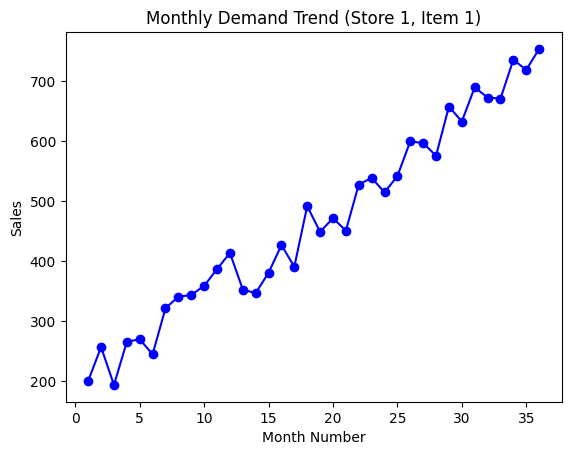

In [30]:
# visulize the 
plt.plot(ds['month_num'], ds['sales'], 'bo-')
plt.xlabel('Month Number')
plt.ylabel('Sales')
plt.title('Monthly Demand Trend (Store 1, Item 1)')
plt.show()

In [52]:
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

y_pred = model.predict(X_poly)

In [53]:
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
print("R² Score:", r2)
print("Mean Squared Error:", mse)

R² Score: 0.9722566290934233
Mean Squared Error: 704.0088442825642


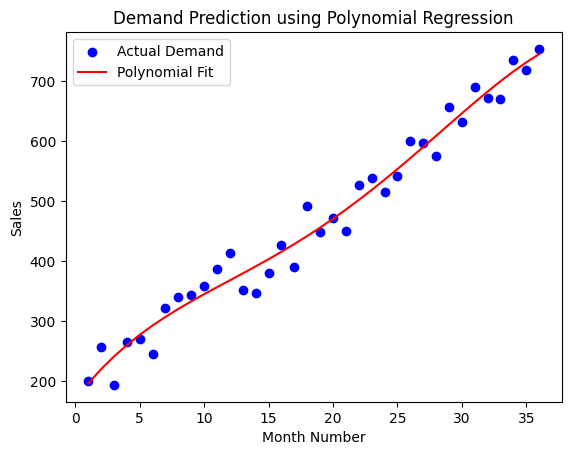

In [54]:
plt.scatter(X, y, color='blue', label='Actual Demand')
plt.plot(X, y_pred, color='red', label='Polynomial Fit')
plt.xlabel('Month Number')
plt.ylabel('Sales')
plt.title('Demand Prediction using Polynomial Regression')
plt.legend()
plt.show()

In [55]:
future_months = np.array([len(df)+1, len(df)+2, len(df)+3]).reshape(-1,1)
future_poly = poly.transform(future_months)
future_sales = model.predict(future_poly)
print("Predicted Demand for Next 3 Months:", future_sales)

Predicted Demand for Next 3 Months: [757.23379275 767.12337733 774.61805804]


C:\Users\NARESH\.conda\envs\MRI\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


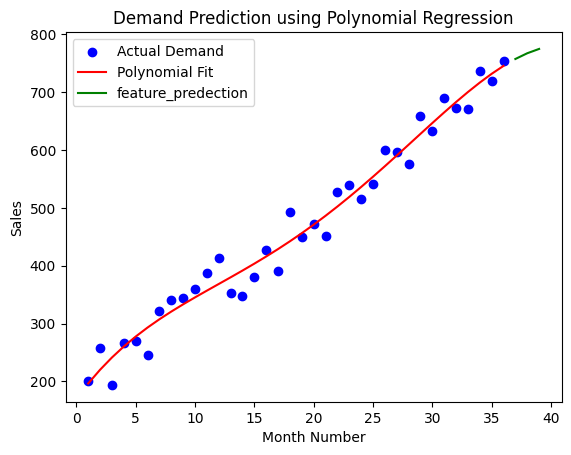

In [56]:
plt.scatter(X, y, color='blue', label='Actual Demand')
plt.plot(X, y_pred, color='red', label='Polynomial Fit')
plt.plot(future_months,future_sales , color='green',label='feature_predection')
plt.xlabel('Month Number')
plt.ylabel('Sales')
plt.title('Demand Prediction using Polynomial Regression')
plt.legend()
plt.show()